In [2]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


Text(0.5, 1.0, '0')

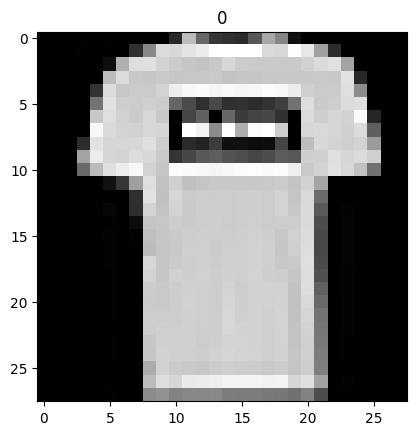

In [3]:
# 데이터 불러오기
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

print(x_train.shape)
print(x_test.shape)

import matplotlib.pyplot as plt
plt.imshow(x_train[1],cmap="gray")
plt.title(y_train[1])

In [4]:
import sys
for x in x_train[1]:
    for i in x:
        sys.stdout.write("%-3s" % i) # 첫번째행 오른쪽 3자리수 맞추어서 출력
    sys.stdout.write('\n')

0  0  0  0  0  1  0  0  0  0  41 18810354 48 43 87 16813316 0  0  0  0  0  0  0  0  
0  0  0  1  0  0  0  49 13621921622823625525525525521721525423116045 0  0  0  0  0  
0  0  0  0  0  14 1762222242122031981962002152042022012012012092182241640  0  0  0  
0  0  0  0  0  18821920019820219819919920119619819820020020020020120022541 0  0  0  
0  0  0  0  51 2191992032032122382482502452492462472522482352072032032221400  0  0  
0  0  0  0  11622620620420720410175 47 73 48 50 45 51 63 1132222022062202240  0  0  
0  0  0  0  2002222092032152000  70 98 0  10359 68 71 49 0  21920621421025038 0  0  
0  0  0  0  2472182122102152140  2542431392551742512552050  21521721420822095 0  0  
0  0  0  45 2262142142152242050  42 35 60 16 17 12 13 70 0  1892162122062121560  0  
0  0  0  16423521421122021620152 71 89 94 83 78 70 76 92 87 2062072222132192080  0  
0  0  0  1061872232372482111982522502482452482522532502522392012122252151931130  0  
0  0  0  0  0  17 54 15922219320819219720020020020020120319521016

In [5]:
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [6]:
# 정규화
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# CNN 입력 형태 
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

# CNN 모델링

model = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32,(3,3),activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.3),
    Dense(10,activation="softmax")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


# 평가
loss , accuracy = model.evaluate(x_test,y_test)
print("정확도",  accuracy)


(60000, 28, 28, 1)
(10000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8422 - loss: 0.4453 - val_accuracy: 0.8781 - val_loss: 0.3300
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8904 - loss: 0.3056 - val_accuracy: 0.8992 - val_loss: 0.2734
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9035 - loss: 0.2648 - val_accuracy: 0.9033 - val_loss: 0.2640
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9132 - loss: 0.2347 - val_accuracy: 0.9002 - val_loss: 0.2854
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9213 - loss: 0.2138 - val_accuracy: 0.9124 - val_loss: 0.2430
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9291 - loss: 0.1922 - val_accuracy: 0.9157 - val_loss: 0.2414
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9327 - loss: 0.1785 - val_accuracy: 0.9152 - val_loss: 0.2450
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9385 - loss: 0.1642 - 

In [7]:
model.save("fashion_mnist_cnn.keras")

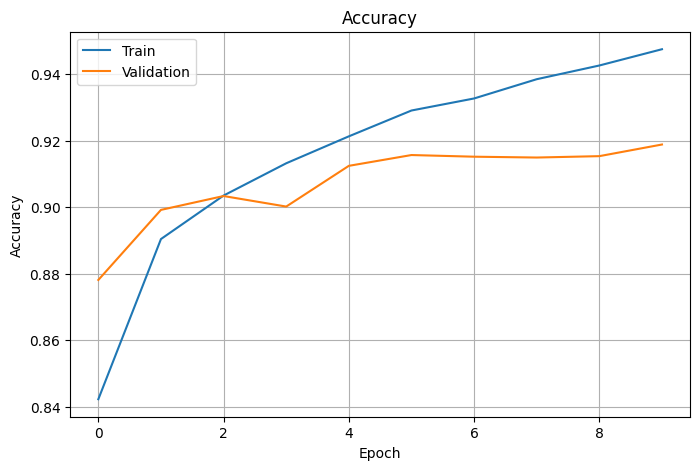

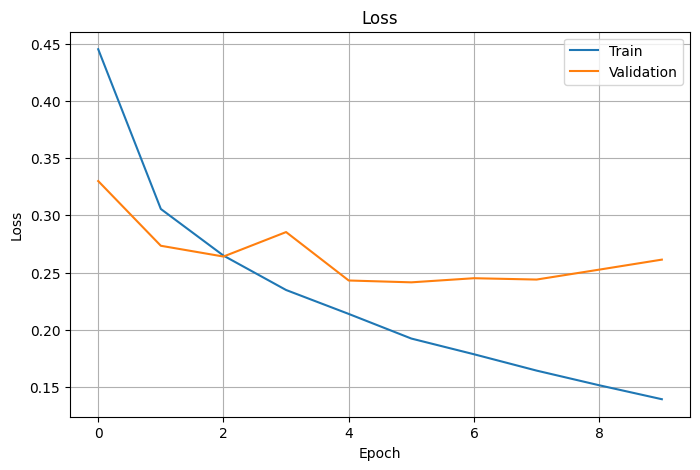

In [8]:
#------------------------------------
# Accuracy 그래프
#------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Train")
plt.plot(history.history["val_accuracy"],label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

#------------------------------------
# Loss 그래프
#------------------------------------

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [9]:
# 파라미터 조정

# Conv2D 필터 수: 32 → 64 → 128
# 커널 크기: 3×3 vs 5×5
# MaxPooling2D 제거 또는 추가
# Dropout(0.3) 추가 전후 비교
# Epoch: 5, 10, 20
# Optimizer: Adam vs SGD
# Batch Size: 16, 32, 64